# ML-08 — Capstone Modeling Lane

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Method choice and why

*Which method from the toolkit, and why it fits your lane.*

**Method: Clustering**

The method is clustering because we have no ground truth, and i am dealing with unlabelled data. and see if the groups emerges from the features selected. we don't know what each group is yet.

## 2. Split design

*Grouped by client? Time-aware? Say why this split is honest for your question.*

Split design is time-aware because we are accounting for cluster stability over time, and a single feature can change. we want to use previous data to predict the future


In [26]:
from google.colab import userdata
from huggingface_hub import login

hf_token = userdata.get("HF_TOKEN")
login(token=hf_token)

In [27]:
from huggingface_hub import HfApi
api = HfApi()
files = api.list_repo_files("FlyRank/internship-warehouse", repo_type="dataset")

r_files = [ f for f in files if "fact_content_daily_performance" in f]
for r in r_files:
  print(r)

fact_content_daily_performance/month=2025-01/data_0.parquet
fact_content_daily_performance/month=2025-02/data_0.parquet
fact_content_daily_performance/month=2025-03/data_0.parquet
fact_content_daily_performance/month=2025-04/data_0.parquet
fact_content_daily_performance/month=2025-05/data_0.parquet
fact_content_daily_performance/month=2025-06/data_0.parquet
fact_content_daily_performance/month=2025-07/data_0.parquet
fact_content_daily_performance/month=2025-08/data_0.parquet
fact_content_daily_performance/month=2025-09/data_0.parquet
fact_content_daily_performance/month=2025-10/data_0.parquet
fact_content_daily_performance/month=2025-11/data_0.parquet
fact_content_daily_performance/month=2025-12/data_0.parquet
fact_content_daily_performance/month=2026-01/data_0.parquet
fact_content_daily_performance/month=2026-02/data_0.parquet
fact_content_daily_performance/month=2026-03/data_0.parquet
fact_content_daily_performance/month=2026-04/data_0.parquet
fact_content_daily_performance/month=202

In [28]:
from datasets import load_dataset
import pandas as pd

cols_needed = [ 'content_hash_id', 'report_date', 'gsc_impressions', 'gsc_clicks',  'gsc_avg_position', 'gsc_data_available']

ds_train = load_dataset("FlyRank/internship-warehouse",
    data_files="fact_content_daily_performance/month=2026-03/data_0.parquet",
    split="train", token=hf_token)
df_train_source = ds_train.select_columns(cols_needed).to_pandas()
del ds_train

ds_test_raw = load_dataset("FlyRank/internship-warehouse",
    data_files="fact_content_daily_performance/month=2026-06/data_0.parquet",
    split="train", token=hf_token)
ds_test = ds_test_raw.shuffle(seed=42).select(range(100_000))
df_test_source = ds_test.select_columns(cols_needed).to_pandas()
del ds_test_raw, ds_test

cols_needed = [ 'content_hash_id', 'word_count', 'is_published', 'content_updated_date']
ds_content = load_dataset("FlyRank/internship-warehouse",
    data_files="dim_content.parquet", split="train", token=hf_token)
df_content = ds_content.select_columns(cols_needed).to_pandas()
del ds_content

df_train_source = df_train_source.merge(df_content, on="content_hash_id", how="left", validate="m:1")
df_test_source = df_test_source.merge(df_content, on="content_hash_id", how="left", validate="m:1")

df_train_source = df_train_source[df_train_source['gsc_data_available'] == True]
df_test_source = df_test_source[df_test_source['gsc_data_available'] == True]


In [29]:
zero_pos = df_train_source[df_train_source['gsc_avg_position'] == 0]

# do these rows have real impressions/clicks, or are they also blank everywhere else?
print(zero_pos[['gsc_impressions', 'gsc_clicks']].describe())

# compare to NaN-position rows - are they behaviorally different from position==0 rows, or the same?
nan_pos = df_train_source[df_train_source['gsc_avg_position'].isna()]
print(nan_pos[['gsc_impressions', 'gsc_clicks']].describe())

# do ANY position==0 rows have nonzero clicks? that would be strong evidence it's a real measurement
print((zero_pos['gsc_clicks'] > 0).sum(), "of", len(zero_pos))

       gsc_impressions     gsc_clicks
count    163189.000000  163189.000000
mean          2.872412       0.007194
std           7.855000       0.086377
min           1.000000       0.000000
25%           1.000000       0.000000
50%           1.000000       0.000000
75%           3.000000       0.000000
max        1125.000000       3.000000
       gsc_impressions  gsc_clicks
count              0.0         0.0
mean               NaN         NaN
std                NaN         NaN
min                NaN         NaN
25%                NaN         NaN
50%                NaN         NaN
75%                NaN         NaN
max                NaN         NaN
1151 of 163189


In [30]:
print(df_train_source.shape)
print(df_test_source.shape)

(3611061, 9)
(33420, 9)


In [31]:
df_train_source['report_date'] = pd.to_datetime(df_train_source['report_date'])
df_train_source['content_updated_date'] = pd.to_datetime(df_train_source['content_updated_date'])
df_test_source['report_date'] = pd.to_datetime(df_test_source['report_date'])
df_test_source['content_updated_date'] = pd.to_datetime(df_test_source['content_updated_date'])


df_train_source['word_count_is_stale_safe'] = (
    df_train_source['content_updated_date'].isna() |
    (df_train_source['content_updated_date'] <= df_train_source['report_date'])
)
df_test_source['word_count_is_stale_safe'] = (
    df_test_source['content_updated_date'].isna() |
    (df_test_source['content_updated_date'] <= df_test_source['report_date'])
)

print(df_train_source['word_count_is_stale_safe'].value_counts(normalize=True))
print(df_test_source['word_count_is_stale_safe'].value_counts(normalize=True))

word_count_is_stale_safe
False    0.820345
True     0.179655
Name: proportion, dtype: float64
word_count_is_stale_safe
True     0.671993
False    0.328007
Name: proportion, dtype: float64


In [32]:
df_train_source.describe()

,report_date,gsc_impressions,gsc_clicks,gsc_avg_position,word_count,content_updated_date
count,3611061,3.611061e+06,3.611061e+06,3.611061e+06,2.405635e+06,3611061
mean,2026-03-16 13:20:26.199503872,7.772164e+01,2.275874e-01,1.582665e+01,2.938671e+03,2026-05-19 00:10:48.670959104
min,2026-03-01 00:00:00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2025-06-01 00:00:00
25%,2026-03-09 00:00:00,4.000000e+00,0.000000e+00,3.742120e+00,2.454000e+03,2026-05-18 00:00:00
50%,2026-03-17 00:00:00,1.600000e+01,0.000000e+00,7.500000e+00,2.769000e+03,2026-05-20 00:00:00
75%,2026-03-24 00:00:00,6.200000e+01,0.000000e+00,2.020000e+01,3.246000e+03,2026-06-22 00:00:00
max,2026-03-31 00:00:00,4.008400e+04,2.740000e+02,4.980000e+02,2.934100e+04,2026-07-06 00:00:00
std,NaN,2.498747e+02,1.277267e+00,1.985603e+01,1.132695e+03,NaN


In [33]:
df_test_source.describe()

,report_date,gsc_impressions,gsc_clicks,gsc_avg_position,word_count,content_updated_date
count,33420,33420.000000,33420.000000,33420.000000,25981.000000,33420
mean,2026-06-15 13:38:35.116696832,58.307062,0.230551,21.208941,2915.259998,2026-05-24 18:03:44.919209984
min,2026-06-01 00:00:00,1.000000,0.000000,0.000000,34.000000,2025-07-10 00:00:00
25%,2026-06-08 00:00:00,3.000000,0.000000,5.600000,2512.000000,2026-05-20 00:00:00
50%,2026-06-16 00:00:00,10.000000,0.000000,10.000000,2784.000000,2026-05-29 00:00:00
75%,2026-06-23 00:00:00,35.000000,0.000000,28.836039,3142.000000,2026-06-25 00:00:00
max,2026-06-30 00:00:00,20104.000000,147.000000,479.000000,9606.000000,2026-07-06 00:00:00
std,NaN,273.291978,1.521843,24.271492,900.329078,NaN


## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

In [34]:
import numpy as np
#Removing bad data, gsc_avg_position at 0, because most have near 0 impressions and clicks, indicating bad data for high position
#it should start at 1
df_train_source.loc[df_train_source['gsc_avg_position'] == 0, 'gsc_avg_position'] = np.nan
df_test_source.loc[df_test_source['gsc_avg_position'] == 0, 'gsc_avg_position'] = np.nan

df_train = df_train_source[df_train_source['gsc_avg_position'].notna()].copy()
df_test = df_test_source[df_test_source['gsc_avg_position'].notna()].copy()

df_train["CTR"] = (df_train["gsc_clicks"] / df_train["gsc_impressions"]) * 100
df_test["CTR"] = (df_test["gsc_clicks"] / df_test["gsc_impressions"]) * 100


df_train.sort_values(by=['content_hash_id', 'report_date'], ascending=True, inplace=True)
df_test.sort_values(by=['content_hash_id', 'report_date'], ascending=True, inplace=True)

df_train['report_date'] = pd.to_datetime(df_train['report_date'])
df_test['report_date'] = pd.to_datetime(df_test['report_date'])

for d in [df_train, df_test]:
    pos_diff = d.groupby('content_hash_id')['gsc_avg_position'].diff()
    days_diff = d.groupby('content_hash_id')['report_date'].diff().dt.days
    d['trend_direction'] = (pos_diff / days_diff).fillna(0)



df_train.loc[~df_train['word_count_is_stale_safe'], 'word_count'] = np.nan
df_test.loc[~df_test['word_count_is_stale_safe'], 'word_count'] = np.nan

In [35]:
df_train['pos_bucket'] = pd.cut(df_train['gsc_avg_position'], bins=[0,3,10,20,100,500])
df_test['pos_bucket'] = pd.cut(df_test['gsc_avg_position'], bins=[0,3,10,20,100,500])

In [36]:
import numpy as np



df_train['word_count'] = df_train.groupby('pos_bucket', observed=True)['word_count'].transform(
    lambda x: x.fillna(x.median())
)

df_test['word_count'] = df_test.groupby('pos_bucket', observed=True)['word_count'].transform(
    lambda x: x.fillna(x.median())
)

for col in ['gsc_impressions', 'gsc_avg_position', 'word_count', 'CTR']:
    df_train[col] = np.log1p(df_train[col])
    df_test[col] = np.log1p(df_test[col])

for col in ['CTR','word_count', 'gsc_impressions', 'gsc_clicks']:
    train_median = df_train[col].median()
    test_median = df_test[col].median()

    df_train[col] = df_train[col].fillna(train_median)
    df_test[col] = df_test[col].fillna(test_median)

df_train['trend_direction'] = np.sign(df_train['trend_direction']) * np.log1p(np.abs(df_train['trend_direction']))
df_test['trend_direction'] = np.sign(df_test['trend_direction']) * np.log1p(np.abs(df_test['trend_direction']))


feature_cols = ["gsc_impressions", "gsc_avg_position", "word_count", "CTR", "trend_direction"]


In [37]:
df_train = df_train[(df_train['is_published'] == True) & (df_train['gsc_avg_position'] <= 100)]
df_test = df_test[(df_test['is_published'] == True) & (df_test['gsc_avg_position'] <= 100)]

                  gsc_avg_position  trend_direction  gsc_impressions  \
gsc_avg_position          1.000000         0.294222        -0.201575   
trend_direction           0.294222         1.000000        -0.004729   
gsc_impressions          -0.201575        -0.004729         1.000000   
gsc_clicks               -0.087362        -0.004355         0.304544   
word_count                0.520948         0.141249        -0.050663   
CTR                      -0.112744        -0.011872         0.186657   

                  gsc_clicks  word_count       CTR  
gsc_avg_position   -0.087362    0.520948 -0.112744  
trend_direction    -0.004355    0.141249 -0.011872  
gsc_impressions     0.304544   -0.050663  0.186657  
gsc_clicks          1.000000   -0.047883  0.352535  
word_count         -0.047883    1.000000 -0.060200  
CTR                 0.352535   -0.060200  1.000000  


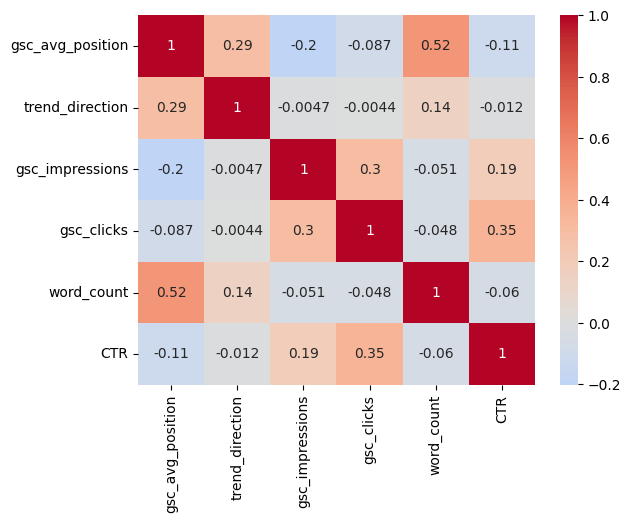

In [38]:
corr = df_train[["gsc_avg_position", "trend_direction", "gsc_impressions",
                       "gsc_clicks", "word_count", "CTR"]].corr()
print(corr)


import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.show()

In [39]:
df_train["word_count"].isna().sum()

np.int64(0)

In [40]:
print("Total df_train rows:", len(df_train))
print("Rows with position == 0:", (df_train['gsc_avg_position'] == 0).sum())
print("Rows with position NaN:", df_train['gsc_avg_position'].isna().sum())
print("Min position:", df_train['gsc_avg_position'].min())

Total df_train rows: 3445970
Rows with position == 0: 0
Rows with position NaN: 0
Min position: 0.0003105858018237479


In [41]:
from sklearn.preprocessing import QuantileTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd

feature_cols = ["gsc_impressions", "word_count", "CTR", "trend_direction", "gsc_avg_position"]

df_train_k = df_train[feature_cols]
df_test_k = df_test[feature_cols]

scaler = QuantileTransformer(output_distribution='normal', random_state=42)
X_train_scaled = scaler.fit_transform(df_train_k).astype(np.float32)
X_test_scaled = scaler.transform(df_test_k).astype(np.float32)


pca = PCA(n_components=3,random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

rng = np.random.RandomState(42)
sample_idx = rng.choice(len(X_train_pca), size=min(1_000_000, len(X_train_pca)), replace=False)
X_sample = X_train_pca[sample_idx]

results = []
for k in range(2, 10):
    km = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=42, max_iter=300)
    labels = km.fit_predict(X_sample)
    score = silhouette_score(X_sample, labels, sample_size=5_000, random_state=42)
    results.append({"k": k, "silhouette_train": score, "inertia": km.inertia_})
    print(f"k={k} | silhouette train: {score:.4f} | inertia: {km.inertia_:,.0f}")

results_df = pd.DataFrame(results)



k=2 | silhouette train: 0.6871 | inertia: 4,254,114
k=3 | silhouette train: 0.6861 | inertia: 2,109,838
k=4 | silhouette train: 0.5277 | inertia: 1,192,798
k=5 | silhouette train: 0.4481 | inertia: 990,042
k=6 | silhouette train: 0.4500 | inertia: 838,148
k=7 | silhouette train: 0.4304 | inertia: 708,687
k=8 | silhouette train: 0.4487 | inertia: 607,353
k=9 | silhouette train: 0.4087 | inertia: 537,842


Why k=3 over the nearly close k=2? k=2 (0.6871) and k=3 (0.6861) are within noise of each other, with the real decline starting at k=4 (0.53).Using k=3, because of the balance between clear  business splits and interpretability

In [42]:
import numpy as np
import pandas as pd
from sklearn.mixture import GaussianMixture
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
best_k =3
gmm = GaussianMixture(n_components=best_k, covariance_type='full', random_state=42, n_init=5)
gmm_train_labels = gmm.fit_predict(X_sample)

agg_sample_idx = np.random.RandomState(42).choice(len(X_sample), size=min(20_000, len(X_sample)), replace=False)
X_agg_sample = X_sample[agg_sample_idx]
agg = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
agg_labels = agg.fit_predict(X_agg_sample)

km_compare = KMeans(n_clusters=best_k, init='k-means++', n_init=20, random_state=42, max_iter=300)
km_labels_full = km_compare.fit_predict(X_sample)
km_labels_agg_sample = km_labels_full[agg_sample_idx]
gmm_labels_agg_sample = gmm_train_labels[agg_sample_idx]

ari_kmeans_gmm = adjusted_rand_score(km_labels_full, gmm_train_labels)
ari_kmeans_agg = adjusted_rand_score(km_labels_agg_sample, agg_labels)
ari_gmm_agg = adjusted_rand_score(gmm_labels_agg_sample, agg_labels)

sil_kmeans = silhouette_score(X_sample, km_labels_full, sample_size=5_000, random_state=42)
sil_gmm = silhouette_score(X_sample, gmm_train_labels, sample_size=5_000, random_state=42)
sil_agg = silhouette_score(X_agg_sample, agg_labels)

seeds = [0, 1, 7, 21, 42, 99]
seed_labels = []
for seed in seeds:
    km_seed = KMeans(n_clusters=best_k, init='k-means++', n_init=20, random_state=seed, max_iter=300)
    seed_labels.append(km_seed.fit_predict(X_sample))

pairwise_aris = []
for i in range(len(seeds)):
    for j in range(i + 1, len(seeds)):
        pairwise_aris.append(adjusted_rand_score(seed_labels[i], seed_labels[j]))

rng = np.random.RandomState(42)
X_shuffled = X_sample.copy()
for col in range(X_shuffled.shape[1]):
    rng.shuffle(X_shuffled[:, col])

km_shuffled = KMeans(n_clusters=best_k, init='k-means++', n_init=20, random_state=42, max_iter=300)
shuffled_labels = km_shuffled.fit_predict(X_shuffled)
sil_shuffled = silhouette_score(X_shuffled, shuffled_labels, sample_size=5_000, random_state=42)

results = pd.DataFrame([
    {"check": "KMeans vs GMM (ARI)", "value": round(ari_kmeans_gmm, 4)},
    {"check": "KMeans vs Agglomerative (ARI)", "value": round(ari_kmeans_agg, 4)},
    {"check": "GMM vs Agglomerative (ARI)", "value": round(ari_gmm_agg, 4)},
    {"check": "Silhouette - KMeans", "value": round(sil_kmeans, 4)},
    {"check": "Silhouette - GMM", "value": round(sil_gmm, 4)},
    {"check": "Silhouette - Agglomerative", "value": round(sil_agg, 4)},
    {"check": "KMeans seed stability - mean pairwise ARI", "value": round(np.mean(pairwise_aris), 4)},
    {"check": "KMeans seed stability - min pairwise ARI", "value": round(np.min(pairwise_aris), 4)},
    {"check": "Silhouette - real data", "value": round(sil_kmeans, 4)},
    {"check": "Silhouette - column-shuffled data", "value": round(sil_shuffled, 4)},
])

print(results.to_string(index=False))

print("\n--- Outcome ---")
print(f"Cross-algorithm agreement (ARI) is {min(ari_kmeans_gmm, ari_kmeans_agg, ari_gmm_agg):.4f}, "
      f"and seed stability is {np.min(pairwise_aris):.4f}, indicating the {best_k}-cluster split "
      f"is a stable, algorithm-independent structure rather than a k-means-specific artifact.")
print(f"Silhouette drops from {sil_kmeans:.4f} on real data to {sil_shuffled:.4f} on column-shuffled data. "
      f"The drop confirms real cross-feature relationships contribute to the structure, but the shuffled "
      f"score is still fairly high in absolute terms, meaning part of the silhouette score reflects the "
      f"shape of individual feature distributions rather than purely relationships between features.")

                                    check  value
                      KMeans vs GMM (ARI) 1.0000
            KMeans vs Agglomerative (ARI) 1.0000
               GMM vs Agglomerative (ARI) 1.0000
                      Silhouette - KMeans 0.6861
                         Silhouette - GMM 0.6861
               Silhouette - Agglomerative 0.6855
KMeans seed stability - mean pairwise ARI 1.0000
 KMeans seed stability - min pairwise ARI 1.0000
                   Silhouette - real data 0.6861
        Silhouette - column-shuffled data 0.5357

--- Outcome ---
Cross-algorithm agreement (ARI) is 1.0000, and seed stability is 1.0000, indicating the 3-cluster split is a stable, algorithm-independent structure rather than a k-means-specific artifact.
Silhouette drops from 0.6861 on real data to 0.5357 on column-shuffled data. The drop confirms real cross-feature relationships contribute to the structure, but the shuffled score is still fairly high in absolute terms, meaning part of the silhouette sco

k=3 | silhouette test: 0.7508 | inertia: 2,109,838
Explained variance ratio: [0.5171966  0.22696781 0.13956797]
Total variance explained: 88.37%


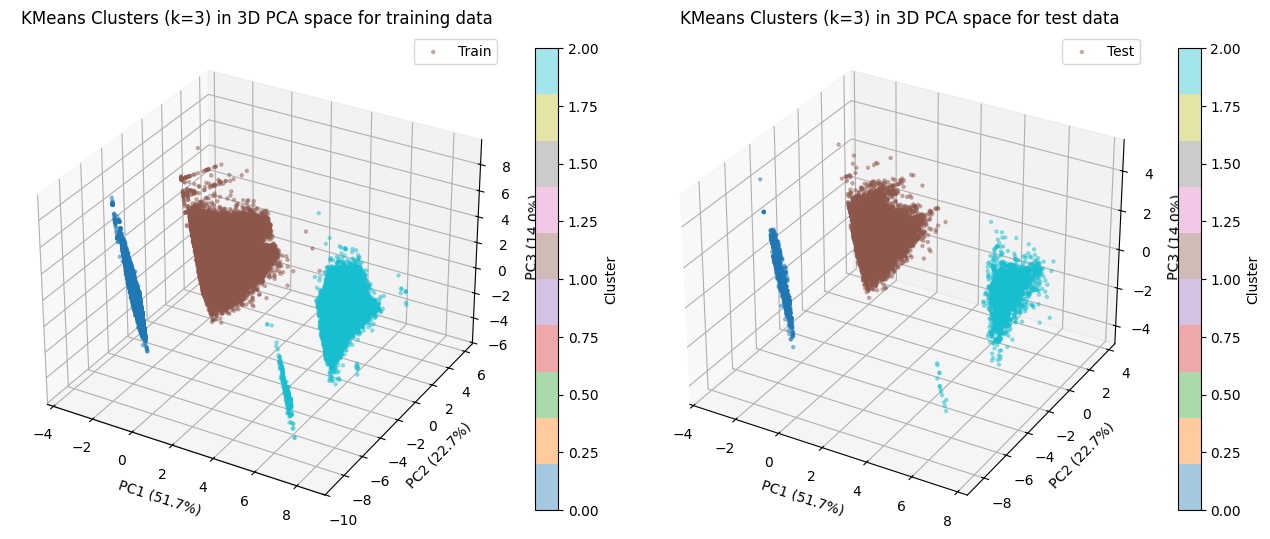

In [43]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

best_k = 3
km_final = KMeans(n_clusters=best_k, init='k-means++', n_init=20, random_state=42, max_iter=300)
train_labels = km_final.fit_predict(X_sample)
test_labels = km_final.predict(X_test_pca)
score_test = silhouette_score(X_test_pca, test_labels, sample_size=5_000, random_state=42)
print(f"k={best_k} | silhouette test: {score_test:.4f} | inertia: {km_final.inertia_:,.0f}")

pca_2 = PCA(n_components=2, random_state=42)
X_train_pca_2 = pca_2.fit_transform(X_sample)
X_test_pca_2 = pca_2.transform(X_test_pca)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.2%}")

fig = plt.figure(figsize=(13, 8))
ax = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')

scatter = ax.scatter(
    X_sample[:, 0], X_sample[:, 1], X_sample[:, 2],
    c=train_labels, cmap='tab10', s=5, alpha=0.4, label='Train'
)

scatter2 = ax2.scatter(
    X_test_pca[:, 0], X_test_pca[:, 1], X_test_pca[:, 2],
    c=test_labels, cmap='tab10', s=5, alpha=0.4, label='Test'
)


ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.set_zlabel(f"PC3 ({pca.explained_variance_ratio_[2]:.1%})")
ax.set_title(f"KMeans Clusters (k={best_k}) in 3D PCA space for training data")
ax.legend()

ax2.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax2.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax2.set_zlabel(f"PC3 ({pca.explained_variance_ratio_[2]:.1%})")
ax2.set_title(f"KMeans Clusters (k={best_k}) in 3D PCA space for test data")
ax2.legend()



plt.colorbar(scatter, ax=ax, label='Cluster', shrink=0.6)
plt.colorbar(scatter2, ax=ax2, label='Cluster', shrink=0.6)
plt.tight_layout()
plt.show()

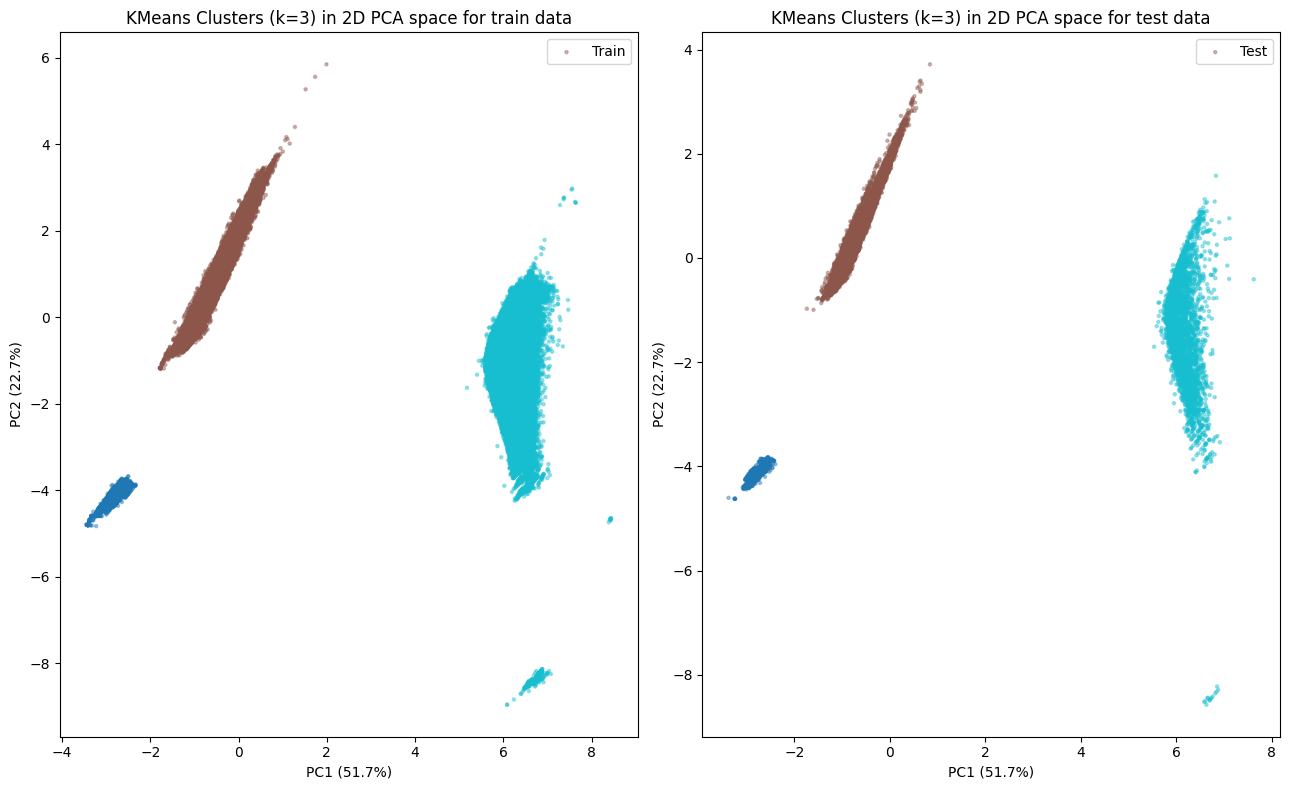

In [44]:
fig = plt.figure(figsize=(13, 8))

ax3 = fig.add_subplot(121)
ax4 = fig.add_subplot(122)



scatter3 = ax3.scatter(
    X_train_pca_2[:, 0], X_train_pca_2[:, 1],
    c=train_labels, cmap='tab10', s=5, alpha=0.4,  label= 'Train'
)

scatter4 = ax4.scatter(
    X_test_pca_2[:, 0], X_test_pca_2[:, 1],
    c=test_labels, cmap='tab10', s=5, alpha=0.4, label='Test'
)

ax3.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax3.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax3.set_title(f"KMeans Clusters (k={best_k}) in 2D PCA space for train data")
ax3.legend()

ax4.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax4.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax4.set_title(f"KMeans Clusters (k={best_k}) in 2D PCA space for test data")
ax4.legend()

plt.tight_layout()
plt.show()

In [45]:
#Compare with baseline

In [51]:
df_train_sample = df_train.loc[df_train_k.index].iloc[sample_idx].copy()
df_train_sample['cluster'] = train_labels

cluster_profile = df_train_sample.groupby('cluster')[
    ['gsc_avg_position', 'trend_direction', 'gsc_impressions', 'word_count', 'CTR']
].mean()

readable_profile = cluster_profile.copy()
for col in ['gsc_avg_position', 'gsc_impressions', 'word_count', 'CTR']:
    readable_profile[col] = np.expm1(cluster_profile[col])
readable_profile['trend_direction'] = np.sign(cluster_profile['trend_direction']) * np.expm1(np.abs(cluster_profile['trend_direction']))

print(readable_profile.round(2))
print(df_train_sample['cluster'].value_counts())

         gsc_avg_position  trend_direction  gsc_impressions  word_count   CTR
cluster                                                                      
0                   13.19             0.17             1.00     3566.86  0.00
1                    9.84             0.00            19.41     3773.37  0.00
2                    6.13            -0.03           150.54     3452.66  1.31
cluster
1    792328
2    120684
0     86988
Name: count, dtype: int64


In [47]:
#Using reason code for baseline to compare
from statsmodels.stats.proportion import proportion_confint

position_raw = np.expm1(df_train_sample['gsc_avg_position'].values)
impressions_raw = np.expm1(df_train_sample['gsc_impressions'].values)
clicks_raw = np.expm1(df_train_sample['gsc_clicks'].values)
trend_raw = np.sign(df_train_sample['trend_direction'].values) * np.expm1(np.abs(df_train_sample['trend_direction'].values))

nan_mask = pd.isna(position_raw)

impressions_safe = np.where(impressions_raw <= 0, 1, impressions_raw)
clicks_safe = np.clip(clicks_raw, 0, impressions_safe)
ci_low, ci_high = proportion_confint(clicks_safe, impressions_safe, alpha=0.10, method='wilson')
interval_width = ci_high - ci_low

low_impressions_mask = (~nan_mask) & (interval_width > 0.15)
low_conf_mask = (~nan_mask) & (position_raw > 100)
healthy_mask = (~nan_mask) & (position_raw <= 10) & (~low_impressions_mask)
declining_mask = (~nan_mask) & (position_raw > 10) & (position_raw <= 100) & (trend_raw > 0) & (~low_impressions_mask)

reason_code = np.full(len(df_train_sample), 'WEAK_BUT_STABLE', dtype=object)
reason_code[nan_mask] = 'NO_DATA'
reason_code[low_impressions_mask] = 'LOW_CONFIDENCE_SIGNAL'
reason_code[low_conf_mask] = 'LOW_CONFIDENCE_SIGNAL'
reason_code[healthy_mask] = 'HEALTHY'
reason_code[declining_mask] = 'DECLINING_UNDERPERFORMER'

df_train_sample['baseline_reason_code'] = reason_code
print(pd.Series(reason_code).value_counts())

LOW_CONFIDENCE_SIGNAL       483769
HEALTHY                     330921
DECLINING_UNDERPERFORMER    105194
WEAK_BUT_STABLE              80116
Name: count, dtype: int64


In [48]:
crosstab = pd.crosstab(df_train_sample['cluster'], df_train_sample['baseline_reason_code'], normalize='index')
print(crosstab.round(3))
print(df_train_sample['cluster'].value_counts())

baseline_reason_code  DECLINING_UNDERPERFORMER  HEALTHY  \
cluster                                                   
0                                        0.000    0.000   
1                                        0.116    0.317   
2                                        0.113    0.661   

baseline_reason_code  LOW_CONFIDENCE_SIGNAL  WEAK_BUT_STABLE  
cluster                                                       
0                                     1.000            0.000  
1                                     0.482            0.086  
2                                     0.126            0.100  
cluster
1    792328
2    120684
0     86988
Name: count, dtype: int64


In [49]:
from statsmodels.stats.proportion import proportion_confint

position_raw_test = np.expm1(df_test['gsc_avg_position'].values)
impressions_raw_test = np.expm1(df_test['gsc_impressions'].values)
clicks_raw_test = np.expm1(df_test['gsc_clicks'].values)
trend_raw_test = np.sign(df_test['trend_direction'].values) * np.expm1(np.abs(df_test['trend_direction'].values))

nan_mask_t = pd.isna(position_raw_test)

impressions_safe = np.where(impressions_raw_test <= 0, 1, impressions_raw_test)
clicks_safe = np.clip(clicks_raw_test, 0, impressions_safe)
ci_low, ci_high = proportion_confint(clicks_safe, impressions_safe, alpha=0.10, method='wilson')
interval_width = ci_high - ci_low

low_impressions_mask_t = (~nan_mask_t) & (interval_width > 0.15)
low_conf_mask_t = (~nan_mask_t) & (position_raw_test > 100)
healthy_mask_t = (~nan_mask_t) & (position_raw_test <= 10) & (~low_impressions_mask_t)
declining_mask_t = (~nan_mask_t) & (position_raw_test > 10) & (position_raw_test <= 100) & (trend_raw_test > 0) & (~low_impressions_mask_t)

reason_code_test = np.full(len(df_test), 'WEAK_BUT_STABLE', dtype=object)
reason_code_test[nan_mask_t] = 'NO_DATA'
reason_code_test[low_impressions_mask_t] = 'LOW_CONFIDENCE_SIGNAL'
reason_code_test[low_conf_mask_t] = 'LOW_CONFIDENCE_SIGNAL'
reason_code_test[healthy_mask_t] = 'HEALTHY'
reason_code_test[declining_mask_t] = 'DECLINING_UNDERPERFORMER'

df_test = df_test.copy()
df_test['baseline_reason_code'] = reason_code_test
df_test['cluster'] = test_labels

crosstab_test = pd.crosstab(df_test['cluster'], df_test['baseline_reason_code'], normalize='index')
print(crosstab_test.round(3))
print(df_test['cluster'].value_counts())

baseline_reason_code  DECLINING_UNDERPERFORMER  HEALTHY  \
cluster                                                   
0                                        0.000    0.000   
1                                        0.014    0.228   
2                                        0.013    0.605   

baseline_reason_code  LOW_CONFIDENCE_SIGNAL  WEAK_BUT_STABLE  
cluster                                                       
0                                     1.000            0.000  
1                                     0.593            0.165  
2                                     0.233            0.149  
cluster
1    24728
0     3984
2     3729
Name: count, dtype: int64


**How the comparison works**

Clustering is unsupervised, it has no concept of the Week 4 rule's reason codes. To compare honestly, I profiled each of the 3 clusters on raw feature values first (before looking at the baseline at all), then cross-tabbed cluster assignment against baseline_reason_code to see how much each cluster overlaps with the rule's categories. This is a statement about co-occurrence, not a claim that clustering "recovered" the same labels.

One population note: the baseline rule was originally scored on the full dataset including NO_DATA rows (missing position). The clustering pipeline only includes rows with a valid gsc_avg_position, so this comparison covers the subset of the baseline's population that could actually be clustered.

This crosstab is on the train set, same population as the original Week 5 comparison, but now uses the Wilson interval version of LOW_CONFIDENCE_SIGNAL rather than the old impressions less than 10 cutoff. That makes this a direct before and after on the same rows, only the rule changed.

**Cross-tab: cluster vs baseline reason code (row-normalized, train set)**

| cluster | DECLINING_UNDERPERFORMER | HEALTHY | LOW_CONFIDENCE_SIGNAL | WEAK_BUT_STABLE |
|---|---|---|---|---|
| 0 (weak/no-demand) | 0.000 | 0.000 | 1.000 | 0.000 |
| 1 (engagement-problem) | 0.116 | 0.317 | 0.482 | 0.086 |
| 2 (champions) | 0.113 | 0.661 | 0.126 | 0.100 |

**Cluster 0, weak/no-demand: perfect agreement, unchanged.** 100% of these rows still fall under LOW_CONFIDENCE_SIGNAL, exactly as before, but now under a completely different definition of low confidence. That's a stronger result than the original claim, since the overlap isn't coming from two methods both reacting to the same arbitrary count of 10, it holds under a statistically grounded interval instead.

**Cluster 2, champions: overlap with HEALTHY dropped from 72.8% to 66.1%.** LOW_CONFIDENCE_SIGNAL inside this cluster rose from 3.2% to 12.6%. Some pages that cleared the old raw impression cutoff and were scored HEALTHY are now flagged as low confidence under the Wilson interval, their click volume passed a raw count but wasn't enough to pin down a stable CTR. DECLINING_UNDERPERFORMER moved only slightly, 12.9% before, 11.3% now.

**Cluster 1, engagement-problem pages: still splits across all four codes, but the shape shifted.** LOW_CONFIDENCE_SIGNAL is now the largest single code in this cluster at 48.2%, up from 36.4%, while HEALTHY dropped from 37.7% to 31.7% and DECLINING_UNDERPERFORMER dropped from 15.0% to 11.6%. This cluster is defined by real impressions with zero clicks and a flat trend, exactly the profile that produces a wide Wilson interval, so more of it now reads as statistically low confidence instead of getting sorted into HEALTHY or DECLINING based on position alone.

**Takeaway:** the core finding holds on train as well as test, this cluster is still not a clean match for any single baseline code, and the rule still has no dedicated logic for "seen but never clicked." What changed is that the Wilson interval rule is more honest about how much of that population it actually has grounds to call HEALTHY or DECLINING versus how much should be flagged as statistically unresolved, and cluster 1 absorbed most of that shift, consistent with what happened on the test set.

## 4. Errors and interpretation

*Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.*

**What the model leans on**

KMeans was fit on 5 features after QuantileTransformer + PCA: gsc_avg_position, trend_direction, gsc_impressions, word_count, and CTR. In practice, position and impressions do most of the separating work, the three clusters read almost entirely as a traffic/rank tier split (champions vs. engagement-problem vs. weak/no-demand). word_count barely differs across clusters (2,535 to 2,797, a narrow band), so it isn't contributing much real separation despite being in the feature set. That means the model is mostly answering "how much traffic and rank does this page have," not picking up finer distinctions like content quality or topic.

**Where it's wrong, or at least misleading, without cleanup**

Before fixing two data issues, the clustering was actively wrong in an informative way:

- **A fabricated cluster from gsc_avg_position == 0.** GSC position is 1-indexed, a true value of 0 isn't a valid measurement. I found ~163k rows (4.5% of non-null position rows) with gsc_avg_position exactly 0 despite having real impressions and even some real clicks, meaning the position field failed to populate for these rows independently of impressions or clicks (confirmed via gsc_sum_position, which was also exactly 0 for all of them despite nonzero impressions). Left in, these rows collapsed into their own fake "best possible rank, zero traffic" cluster, and inflated silhouette score by giving KMeans an artificially easy, perfectly separated group to split on. After nulling gsc_avg_position for these rows and excluding them from clustering, best_k changed from 4 to 3, and silhouette at k=4 dropped from 0.71 to 0.47. The original k=4 choice was partly measuring a data bug, not real structure.
- **A secondary artifact from median-imputing word_count.** Rows with missing word_count were originally filled with one global median, which stacked thousands of otherwise-different rows onto an identical point and let KMeans treat "missingness" as if it were a real content signal. Switching to a group-wise median (by position bucket) spread the imputed values out and reduced, though didn't fully eliminate, this effect.

**Where the model still disagrees with the baseline, and what that means**

The cross-tab in Section 3 shows the model doesn't cleanly reproduce the baseline's DECLINING_UNDERPERFORMER or WEAK_BUT_STABLE categories, both get smeared across clusters rather than concentrating in one. This holds even after rebuilding LOW_CONFIDENCE_SIGNAL around a Wilson interval on CTR instead of the old raw impressions cutoff, so it isn't an artifact of one arbitrary threshold, it's a structural mismatch between the two methods. trend_direction is one of five features and gets averaged into an overall traffic and rank profile, while the baseline rule applies it as a hard, standalone cutoff (trend greater than 0). A page with a sharp recent decline but otherwise strong historical traffic can still land in the champions cluster, since the clustering sees the whole pattern, not the most recent data point in isolation.

The Wilson interval change did shift where cluster 1 lands, though. LOW_CONFIDENCE_SIGNAL inside cluster 1 rose from 36.4% to 48.2% once the rule started checking whether the CTR estimate was statistically stable instead of just counting impressions, while HEALTHY and DECLINING_UNDERPERFORMER both dropped a few points. That's consistent with what cluster 1 actually is, real impressions with zero clicks and a flat trend, which is exactly the shape that produces a wide confidence interval. The rule catching more of this cluster as low confidence isn't the clustering changing, it's the baseline getting more honest about a population it was previously misclassifying as HEALTHY or DECLINING on the strength of position and impressions alone, without any real basis for trusting the click signal underneath.

This isn't a bug in either method, it's a structural difference: the rule is a point-in-time trigger, the clustering is a summary of overall behavior.

**Biggest real limitation**

No article text, topic, or query-level data is available in this feature set, so the model can't detect anything content-quality or cannibalization related. It's also blind to time within a cluster, a champion today and a champion declining toward engagement-problem status look similar until the decline is severe enough to actually move the point in PCA space. This is a real error mode worth naming rather than hiding: the clustering is a snapshot, not an early-warning system.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.